# Football Valuator MLOps — Modelo

Notebook de entrenamiento del modelo de predicción del valor de mercado de futbolistas.

**Algoritmo final:** Gradient Boosting Regressor con transformación logarítmica del target.

**Target:** `valor_ajustado_2025` (valor en € ajustado a inflación 2025)

**Pipeline:**
1. Cargar dataset procesado
2. Preparar features (one-hot encoding)
3. Train/test split
4. **Iteración 1:** Random Forest baseline
5. **Iteración 2:** Gradient Boosting + log target (FINAL)
6. Evaluación y guardado del modelo

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib
import os

# Configuración
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.0f}')

print('✓ Librerías cargadas')

✓ Librerías cargadas


In [2]:
# Cargar el dataset procesado por el notebook anterior
dataset = pd.read_csv('../data/processed/dataset_modelo.csv')

print(f'✓ Dataset cargado: {len(dataset):,} filas, {len(dataset.columns)} columnas')
dataset.head()

✓ Dataset cargado: 123,498 filas, 23 columnas


,player_id,name,date,valor_ajustado_2025,market_value_in_eur,edad,edad_cuadrado,position,sub_position,foot,height_in_cm,country_of_citizenship,es_internacional,goles_ventana,asistencias_ventana,partidos_ventana,minutos_ventana,amarillas_ventana,rojas_ventana,goles_por_minuto,asistencias_por_minuto,ratio_minutos,tier_liga
0,5856,Daniele Bonera,2018-01-01,"214,286",200000,37,"1,339",Defender,Centre-Back,right,183,Italy,False,0,1,30,2409,8,0,0,0,1,1
1,5957,Alberto Aquilani,2018-01-01,"857,143",800000,33,"1,122",Midfield,Central Midfield,right,186,Italy,False,2,1,52,3232,9,0,0,0,1,1
2,7593,Fernando Navarro,2018-01-01,"321,429",300000,36,"1,262",Defender,Left-Back,left,176,Spain,False,0,1,53,4290,11,0,0,0,1,1
3,7600,Andrés Iniesta,2018-01-01,"21,428,571",20000000,34,"1,132",Midfield,Central Midfield,both,171,Spain,False,2,7,82,5693,10,0,0,0,1,1
4,7663,Joaquín,2018-01-01,"535,714",500000,36,"1,329",Attack,Right Winger,right,181,Spain,False,6,9,65,4093,7,0,0,0,1,1


In [3]:
# ============================================================
# PREPARAR FEATURES
# ============================================================

# 1. Separar target (y) y features (X)
y = dataset['valor_ajustado_2025']

columnas_no_features = [
    'player_id', 'name', 'date',
    'market_value_in_eur', 'valor_ajustado_2025'
]
X = dataset.drop(columns=columnas_no_features)

# 2. One-hot encoding de variables categóricas
columnas_categoricas = ['position', 'sub_position', 'foot', 'country_of_citizenship']
X = pd.get_dummies(X, columns=columnas_categoricas, drop_first=True)

# 3. Convertir booleanos a 0/1
X['es_internacional'] = X['es_internacional'].astype(int)

# 4. Rellenar nulos en altura con la mediana
X['height_in_cm'] = X['height_in_cm'].fillna(X['height_in_cm'].median())

print(f'✓ Features preparadas: {X.shape[1]} columnas')
print(f'   Filas: {X.shape[0]:,}')

✓ Features preparadas: 202 columnas
   Filas: 123,498


In [4]:
# ============================================================
# TRAIN / TEST SPLIT (80% / 20%)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# También preparamos las versiones logarítmicas del target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f'✓ Datos divididos:')
print(f'   Entrenamiento: {len(X_train):,} filas (80%)')
print(f'   Test:          {len(X_test):,} filas (20%)')

✓ Datos divididos:
   Entrenamiento: 98,798 filas (80%)
   Test:          24,700 filas (20%)


## Iteración 1 — Baseline: Random Forest

Modelo simple para tener una referencia inicial. No aplicamos transformación al target.

**Hipótesis:** un Random Forest debería capturar gran parte de los patrones, pero el rango brutal del target (de 10K€ a 200M€, ratio 20.000:1) puede dificultar el aprendizaje.

In [5]:
# ============================================================
# ITERACIÓN 1: RANDOM FOREST BASELINE
# ============================================================

print('🌲 Entrenando Random Forest baseline...')

modelo_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    n_jobs=-1,
    random_state=42
)
modelo_rf.fit(X_train, y_train)

# Predicciones y métricas
y_pred_rf = modelo_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print('\n' + '=' * 50)
print('MÉTRICAS — RANDOM FOREST BASELINE')
print('=' * 50)
print(f'MAE:  {mae_rf:,.0f} €')
print(f'RMSE: {rmse_rf:,.0f} €')
print(f'R²:   {r2_rf:.4f}')

🌲 Entrenando Random Forest baseline...

MÉTRICAS — RANDOM FOREST BASELINE
MAE:  4,173,419 €
RMSE: 8,675,712 €
R²:   0.5416


## Iteración 2 — Modelo final: Gradient Boosting + log target

**Mejoras aplicadas tras analizar el baseline:**

1. **Transformación logarítmica del target** (`log1p`): técnica estándar para variables tipo precio. Comprime el rango (de millones a unos pocos números) y hace que los errores sean proporcionales al valor real.

2. **Gradient Boosting Regressor:** algoritmo más potente que Random Forest para problemas de regresión con relaciones complejas. Construye árboles secuencialmente, cada uno corrigiendo los errores del anterior.

In [6]:
# ============================================================
# ITERACIÓN 2: GRADIENT BOOSTING + LOG TARGET (MODELO FINAL)
# ============================================================

print('🚀 Entrenando Gradient Boosting con log target... (~3 min)')

modelo_final = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)
modelo_final.fit(X_train, y_train_log)

# Predicciones (deshacemos el log para evaluar en € reales)
y_pred_log = modelo_final.predict(X_test)
y_pred = np.expm1(y_pred_log)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
r2_log = r2_score(y_test_log, y_pred_log)

print('\n' + '=' * 50)
print('MÉTRICAS — MODELO FINAL')
print('=' * 50)
print(f'MAE:           {mae:,.0f} €')
print(f'RMSE:          {rmse:,.0f} €')
print(f'R² (€):        {r2:.4f}')
print(f'R² (escala log): {r2_log:.4f}  ← más representativo')

🚀 Entrenando Gradient Boosting con log target... (~3 min)

MÉTRICAS — MODELO FINAL
MAE:           3,719,219 €
RMSE:          9,043,853 €
R² (€):        0.5019
R² (escala log): 0.6901  ← más representativo


In [7]:
# ============================================================
# COMPARATIVA DE LAS 2 ITERACIONES
# ============================================================

print('=' * 60)
print('COMPARATIVA DE MODELOS')
print('=' * 60)
print(f'{"Modelo":<35} {"MAE":>13} {"R²":>10}')
print('-' * 60)
print(f'{"Random Forest baseline":<35} {mae_rf:>11,.0f} € {r2_rf:>10.4f}')
print(f'{"GB + log target (FINAL)":<35} {mae:>11,.0f} € {r2_log:>10.4f}')

COMPARATIVA DE MODELOS
Modelo                                        MAE         R²
------------------------------------------------------------
Random Forest baseline                4,173,419 €     0.5416
GB + log target (FINAL)               3,719,219 €     0.6901


## Análisis del modelo final

Evaluación segmentada por rango de valor y top de features más importantes.

In [8]:
# ============================================================
# EVALUACIÓN POR RANGO DE VALOR
# ============================================================

def categorizar(valor):
    if valor < 1_000_000:
        return '1. Bajo (<1M)'
    elif valor < 5_000_000:
        return '2. Medio (1-5M)'
    elif valor < 20_000_000:
        return '3. Alto (5-20M)'
    elif valor < 50_000_000:
        return '4. Élite (20-50M)'
    else:
        return '5. Estrella (>50M)'

categorias = y_test.apply(categorizar)

print('=' * 65)
print('MÉTRICAS POR RANGO DE VALOR')
print('=' * 65)
print(f'{"Categoría":<22} {"N":>8} {"MAE":>15} {"% error":>12}')
print('-' * 65)

for cat in sorted(categorias.unique()):
    mask = categorias == cat
    if mask.sum() == 0:
        continue
    mae_cat = mean_absolute_error(y_test[mask], y_pred[mask])
    pct_error = (mae_cat / y_test[mask].median()) * 100
    print(f'{cat:<22} {mask.sum():>8,} {mae_cat:>13,.0f} € {pct_error:>11.0f}%')

MÉTRICAS POR RANGO DE VALOR
Categoría                     N             MAE      % error
-----------------------------------------------------------------
1. Bajo (<1M)             9,920       457,442 €         107%
2. Medio (1-5M)           7,943     1,787,908 €          83%
3. Alto (5-20M)           4,744     5,345,980 €          62%
4. Élite (20-50M)         1,652    16,861,522 €          60%
5. Estrella (>50M)          441    45,145,073 €          68%


In [9]:
# ============================================================
# TOP 15 FEATURES MÁS IMPORTANTES
# ============================================================

importancias = pd.DataFrame({
    'feature': X.columns,
    'importancia': modelo_final.feature_importances_
}).sort_values('importancia', ascending=False).head(15)

print('=' * 50)
print('TOP 15 FEATURES MÁS IMPORTANTES')
print('=' * 50)
for idx, row in importancias.iterrows():
    print(f'  {row["feature"]:<35} {row["importancia"]*100:>5.1f}%')

TOP 15 FEATURES MÁS IMPORTANTES
  tier_liga                            48.1%
  es_internacional                     15.1%
  minutos_ventana                       8.0%
  edad                                  4.7%
  edad_cuadrado                         4.5%
  goles_ventana                         2.2%
  goles_por_minuto                      2.1%
  ratio_minutos                         2.0%
  height_in_cm                          1.5%
  asistencias_ventana                   1.3%
  asistencias_por_minuto                1.2%
  partidos_ventana                      1.0%
  country_of_citizenship_Brazil         0.9%
  country_of_citizenship_England        0.7%
  country_of_citizenship_Ukraine        0.5%


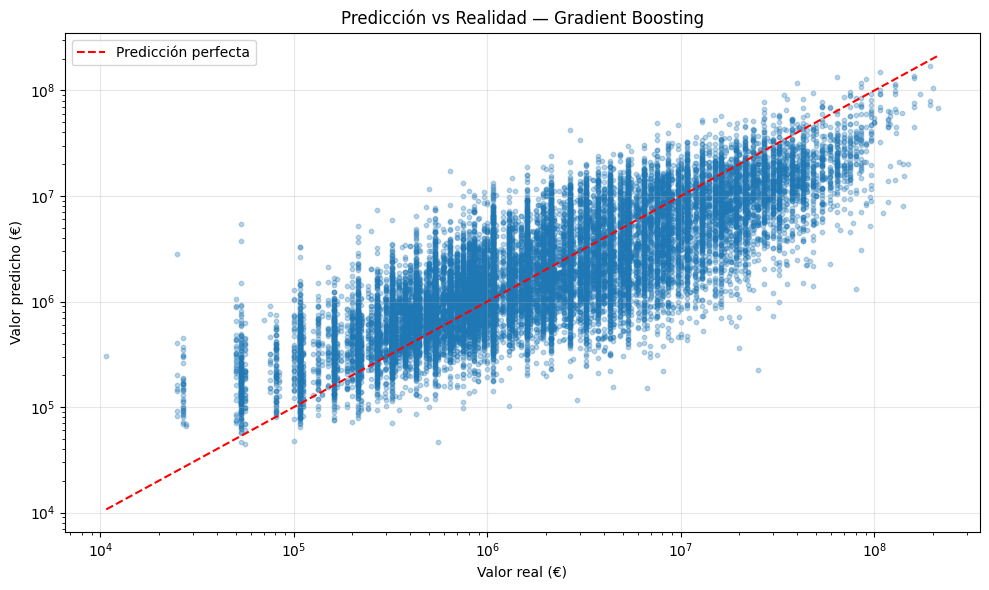

In [10]:
# ============================================================
# GRÁFICO: PREDICCIÓN VS REALIDAD
# ============================================================

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', label='Predicción perfecta')
plt.xlabel('Valor real (€)')
plt.ylabel('Valor predicho (€)')
plt.title('Predicción vs Realidad — Gradient Boosting')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# GUARDAR MODELO FINAL
# ============================================================

os.makedirs('../models', exist_ok=True)

joblib.dump(modelo_final, '../models/modelo_final.pkl')
joblib.dump(X.columns.tolist(), '../models/features.pkl')

print('✓ Modelo guardado en models/modelo_final.pkl')
print(f'✓ {len(X.columns)} features guardadas en models/features.pkl')

print('\n' + '=' * 50)
print('RESUMEN DEL MODELO FINAL')
print('=' * 50)
print(f'Algoritmo:        Gradient Boosting Regressor')
print(f'Target:           log(valor_ajustado_2025)')
print(f'Features:         {len(X.columns)}')
print(f'Filas train:      {len(X_train):,}')
print(f'Filas test:       {len(X_test):,}')
print(f'\nMétricas en test set:')
print(f'  MAE:            {mae:,.0f} €')
print(f'  R² (€):         {r2:.4f}')
print(f'  R² (escala log): {r2_log:.4f}')

✓ Modelo guardado en models/modelo_final.pkl
✓ 202 features guardadas en models/features.pkl

RESUMEN DEL MODELO FINAL
Algoritmo:        Gradient Boosting Regressor
Target:           log(valor_ajustado_2025)
Features:         202
Filas train:      98,798
Filas test:       24,700

Métricas en test set:
  MAE:            3,719,219 €
  R² (€):         0.5019
  R² (escala log): 0.6901
